# 1. Introduction

In the previous notebook, we examined how we can produce the GRS vectors for individuals by making using a pre-trained DL model that takes individual-level genotype data as input, and outputs the GRS vectors. We examined how directly evaluate the predictive performance, check for confounding using delta R2, how we can cluster the GRS scores, and finally how we can potentially use the GRS scores for downstream tasks.

This notebook picks up the thread a bit, in the sense that we will explore a bit more how we can use the GRS scores for other DL related applications. Specifically, we will examine whether we can **train GPT style transformer models for EHR (electronic health record) trajectory generation**, and how we can include the GRS scores as an additional input for the sequence generation model.

## 1.1 What you will do today

- **Simulate ...**

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from integrative_post_gwas.simulate_ehr import main as do_ehr_simulation
from integrative_post_gwas import ehr_utils
from integrative_post_gwas.simulate_ehr import trim_sequence
from integrative_post_gwas import eir_utils
from integrative_post_gwas import latent_analysis as la

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

%load_ext autoreload
%autoreload 2

## 1.2 Training from scratch, or using the pre-trained models

Each of the two `eirtrain` runs below takes around 30 minutes on GitHub Codespaces, which
is more than we have in the session. The repository therefore includes the dataset and the
trained checkpoints under `pretrained/`.

With the switch below left at `False`, the cell restores those into `reference_data/` and
`runs/`, and the simulation and training cells are passed over. Everything after that runs
normally and takes seconds rather than an hour.

> **Note**: leave this at `False` for today. If you want to train it yourself afterwards:
>
> - Re-simulating means retraining, since a checkpoint only works with the data its
>   vocabulary was built from.
> - Delete `runs/ehr_transformer` and `runs/ehr_transformer-with-grs` first, as EIR will
>   not write into a folder that already has a training history.
>
> Email us if you get stuck, the addresses are in the README.

In [2]:
# False: use the pre-trained checkpoints under pretrained/ (seconds).
# True:  simulate and train everything yourself (~1 hour).
TRAIN_FROM_SCRATCH = False

if not TRAIN_FROM_SCRATCH:
    eir_utils.restore_pretrained()

This line here is just ensuring we have a the newest released version of EIR. The reason for that is that the pre-trained DL model we used in the previous notebook was trained with version 0.23.0 of EIR, whereas the version we use here, 0.24.0, includes some bug fixes and improvements for sequence generation.

In [3]:
import importlib.metadata as m
if not m.version("eir-dl").startswith("0.24"):
    !uv pip install "git+https://github.com/arnor-sigurdsson/EIR.git@c7fe5d"

## Data Setup and Simulation

In [4]:
df_labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {df_labels.shape}")
display(df_labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## Data Simulation

Optimally, we would like to train our models on real EHR data where individuals are also genotyped, across multiple lab measurements, diseases and other events. However in this case, we do not have any health trajectory data for our PennCATH dataset. Therefore, we will make a little compromise and *simulate* EHR health data with a simple simulation.

First, let's review a bit what traits we have from the prediction we performed in the previous notebook:

In [5]:
prediction_folder = Path("../output/results/")
predicted_traits = sorted([i.stem for i in prediction_folder.iterdir() if i.suffix == ".csv"])
print(f"Total number of traits: {len(predicted_traits)}\n")
print(f"Preview of traits: {predicted_traits[:10]}")

Total number of traits: 315

Preview of traits: ['Alanine_aminotransferase', 'Albumin_BIOCH', 'Alkaline_phosphatase', 'Apolipoprotein_A', 'Apolipoprotein_A1', 'Apolipoprotein_B_BIOCH', 'Apolipoprotein_B_METAB', 'Aspartate_aminotransferase', 'Average_Diameter_for_HDL_Particles', 'Average_Diameter_for_VLDL_Particles']


So, given we have 315 traits, we are going to choose some of them to simulate the EHR trajectory, and later we will use some of them (different from the ones we use for the simulation) to use as additional inputs for the EHR sequence generation.

> **Note**: Of course this simulation is only for the purpose of this exercise, it's very possible that there is some circularity/bias in how these predicted values relate to each other, but we'll let that slide for now.

### Simulation function

The simulation uses the individual's genetic percentiles for each trait. So, a value of so a value of `84` means e.g. "84th percentile of genetically-predicted LDL".

*Continuous traits*

For a trait with base percentile $p$, measured at `age`, the observed level is

$$
\text{level} = \underbrace{s \cdot (\text{age} - 60)}_{\text{age trend}} + p + \varepsilon,
\qquad
s = 1.5 \left(\tfrac{p}{100}\right), \quad
\varepsilon \sim \mathcal{N}(0, 3.0^2)
$$

So the level changes with age a rate $s$, which is larger for higher precentile individuals. So a higher precentile individual for e.g. LDL will rise faster. This is how we generate the tokens such as `LAB_LDL_Cholesterol_84%`.

> **Question**: Notice how the percentile itself is part of the token here. What are the tradeoffs of doing it like this? For example let's imagine we have tousands of traits, and we make the percentiles more granular (e.g. 91.1%, 91.2%, etc.), how will this affect the total size of the vocabulary? What is a better design decision in that case?

*Categorical traits*

For a trait with risk percentile $p$, the probability
of a *new* diagnosis at a given visit is

$$
P(\text{onset}) = 0.2 \left(\tfrac{p}{100}\right)^2
$$

Once diagnosed, the code is kept, meaning it will then reappear in any subsequent visit with a probabilit of $0.9$.

### Multiple trajectories per individual

As our dataset is relatively small on the scale used for general sequence generation models, we also simulate/draw multiple trajectories per individual (i.e., from their baseline scores) to add additional variation in our dataset. When splitting into train and test sets, we split on the individual level, so we have separate individuals in our training and test sets, but each one of those can be represented with multiple trajectories. 

### Chosen traits

We have chosen a default set of 4 continuous and 3 categorical traits below, but feel free to change them to something else you are interested in. Note that later we will use the following traits as additional inputs to the model: 

`Alanine_aminotransferase`, `Albumin_BIOCH`, `Alkaline_phosphatase`,
`Aspartate_aminotransferase`, `C_reactive_protein`, `Calcium`, `Cholesterol`,
`Creatinine_BIOCH`, `Cystatin_C`, `Direct_bilirubin`, `Gamma_glutamyltransferase`,
`Glycated_haemoglobin_HbA1c`, `IGF_1`, `LDL_direct`, `Lipoprotein_A`, `Phosphate`,
`Total_bilirubin`, `Total_protein`, `Urate`, `Urea`, `Vitamin_D`

So likely you want to choose traits different from these for the generation in case you want to edit these.

In [6]:
con_traits = [
    "HDL_cholesterol",
    "Body_mass_index_BMI_IMPED",
    "Total_Triglycerides",
    "Systolic_blood_pressure_automated_reading"
]

cat_traits = [
    "I10",
    "I25",
    "E11",
]

if TRAIN_FROM_SCRATCH:
    do_ehr_simulation(
        input_root=Path(".."),
        output_folder=Path("../reference_data/eir-transformer"),
        con_traits=con_traits,
        cat_traits=cat_traits,
    )

In [7]:
df_seq_train = pd.read_csv("../reference_data/eir-transformer/df_ehr.csv", index_col=0)

In [8]:
df_seq_train.head(5)

,Sequence
ID,
10002_0,SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol...
10002_1,SEX_1 [VISIT_START] AGE_61 LAB_HDL_cholesterol...
10002_2,SEX_1 [VISIT_START] AGE_62 LAB_HDL_cholesterol...
10002_3,SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol...
10002_4,SEX_1 [VISIT_START] AGE_61 LAB_HDL_cholesterol...


Here we can take a look at how 

In [9]:
example_sequence = df_seq_train.iloc[0]['Sequence']
print(example_sequence)

SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol_40% LAB_Body_mass_index_BMI_IMPED_86% LAB_Total_Triglycerides_70% LAB_Systolic_blood_pressure_automated_reading_20% [VISIT_END] [SEP] [VISIT_START] AGE_67 LAB_HDL_cholesterol_46% LAB_Body_mass_index_BMI_IMPED_96% LAB_Total_Triglycerides_76% LAB_Systolic_blood_pressure_automated_reading_26% [VISIT_END] [SEP] [VISIT_START] AGE_68 LAB_HDL_cholesterol_40% LAB_Body_mass_index_BMI_IMPED_90% LAB_Total_Triglycerides_76% LAB_Systolic_blood_pressure_automated_reading_22% [VISIT_END] [SEP] [VISIT_START] AGE_71 LAB_HDL_cholesterol_44% LAB_Body_mass_index_BMI_IMPED_98% LAB_Total_Triglycerides_78% LAB_Systolic_blood_pressure_automated_reading_28% [VISIT_END] [SEP] [VISIT_START] AGE_73 LAB_HDL_cholesterol_46% LAB_Body_mass_index_BMI_IMPED_100% LAB_Total_Triglycerides_82% LAB_Systolic_blood_pressure_automated_reading_26% DX_I10 [VISIT_END] [SEP] [VISIT_START] AGE_77 LAB_HDL_cholesterol_46% LAB_Body_mass_index_BMI_IMPED_100% LAB_Total_Triglycerides_90% LAB

> **Question**: How many tokens are in this example sequence, assuming we do the simple tokenization of splitting on whitespace? We can use `len()` and `.split()` in Python to check this. How does this compare to the sequence length used in current SOTA LLM models?

In [10]:
# n_tokens = example_sequence
# print(n_tokens)

We can use this little utility function which we imported earlier to visualize how the trajectory changes as a function of age for a given biomarker, and also pass in a chosen disease token to see if/when it is realized in the trajectory.

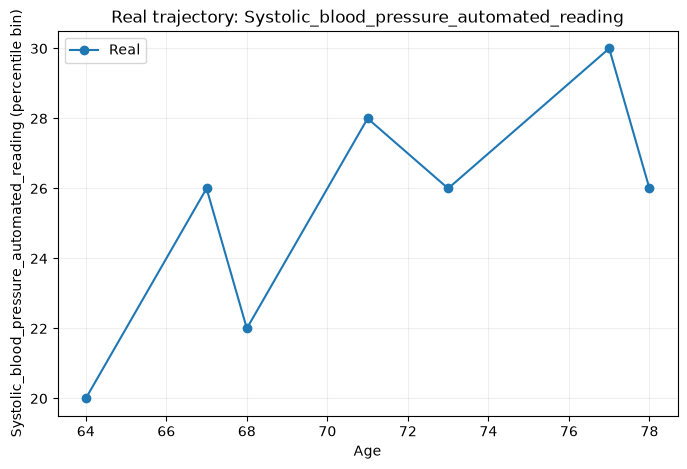

In [11]:
ehr_utils.plot_real_vs_generated(real_seq=example_sequence, generated_seq=None, lab="Systolic_blood_pressure_automated_reading", disease="E11")

# Training

In the previous notebook, we used `EIR-auto-GP` to run a prediction on individual level genotype data with a pre-trained model. Under the hood, `EIR-auto-GP` is using `EIR` for this functionality. Now, we will go one layer down and work with `EIR` itself to train our own model.

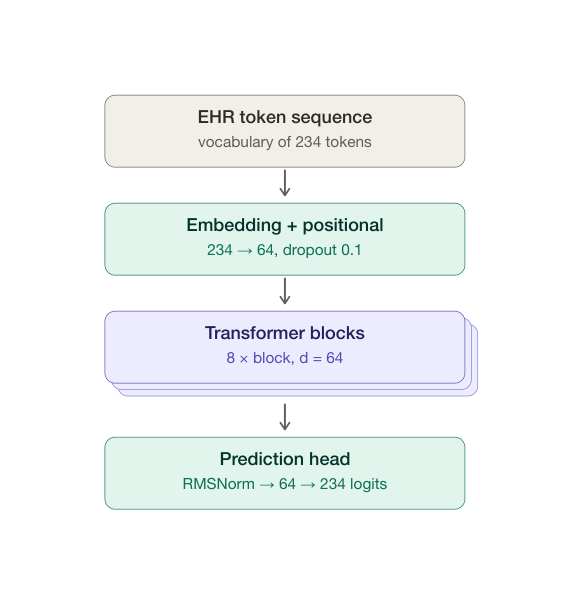

In [12]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/ehr-transformer.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

In [13]:
!cat ../configs/eir-transformer/output_sequence.yaml

output_info:
  output_source: ../reference_data/eir-transformer/df_ehr.csv
  output_name: ehr
  output_type: sequence

model_config:
  embedding_dim: 64
  model_init_config:
    num_layers: 4

output_type_info:
    sampling_strategy_if_longer: "uniform"
    max_length: 64
    split_on: " "
    min_freq: 10

> **Note**: A little quirk of EIR when doing sequence generation and only an output configuration is passed in is that it will "clone" the output configuration and use the supplied parameters to set up the earlier parts of the model, that is why we have 8 Transformer blocks in the diagram above, even though we only passed in 4 here for `num_layers`.

When we originally trained this notebook, we did it on an Macbook Pro laptop from 2023, which includes a GPU accelerator. The training takes ~2-3 minutes when using the accelerator, but when running this on e.g. GitHub Codespaces which only provides a few CPUs, training might take around 30 minutes. Therefore, we provide the small `edit_configs` function there below. Originally, we used 20 epochs (1 epoch = 1 pass over the whole training dataset) with a sequence length of 64. In the case you are on GitHub Codespaces, change this to e.g. `5` epochs and a maximum length of `32`.

In [14]:
# The configs already say 20 epochs and a max length of 64, so this is only needed
# if you want to change them. On GitHub Codespaces, uncomment and use e.g. 5 and 32.
# eir_utils.edit_config(n_epochs=20, max_len=64)

In [15]:
if TRAIN_FROM_SCRATCH:
    !eirtrain \
        --global_configs "../configs/eir-transformer/globals.yaml" \
        --fusion_configs "../configs/eir-transformer/fusion.yaml" \
        --output_configs "../configs/eir-transformer/output_sequence.yaml"

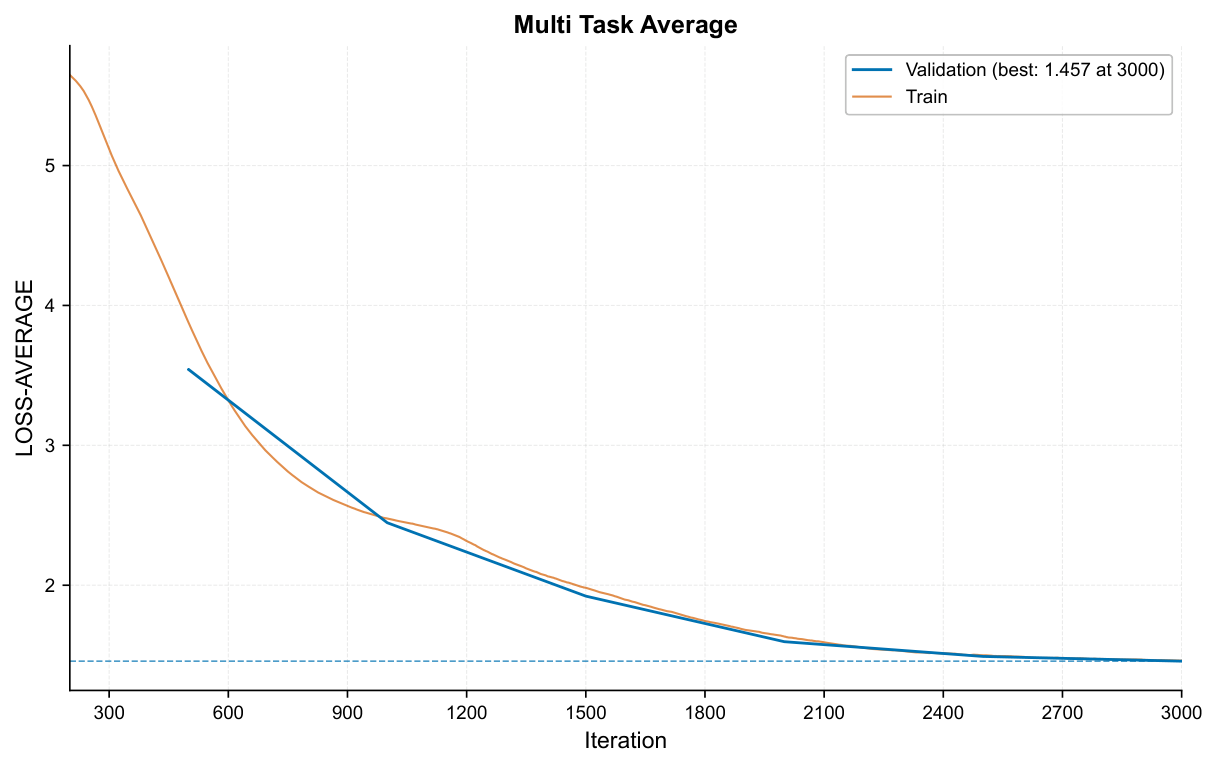

In [16]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

> **Question**: We are currently setting a limit of 20 epochs (how often the neural network sees the training data) in the global configuration so the training finishes in a reasonable amount of time for the lecture. Based on how the loss is developing as a function of iterations in the plot above, do you think this is ultimately a good value assuming we had more time for training? Is the model still improving or has it reached a plateau at the point training is terminated (iteration 3K)?

# Testing sequence generation

In [17]:
full_history = ehr_utils.load_test_sample(index=0)
prompt = trim_sequence(full_history, stop_when=lambda t: t == "[VISIT_END]")

In [18]:
ehr_utils.set_manual_inputs(prompts=prompt)

In [19]:
!eirpredict \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence_test.yaml" \
    --model_path ../runs/ehr_transformer/saved_models/ehr_transformer_* \
    --output_folder "../runs/ehr_transformer/test_set_predictions"

01:52:15 - INFO - eir.train_utils.utils - Global random seed set to 0.


01:52:15 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
01:52:15 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
01:52:15 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.


01:52:15 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_transformer/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:15 - INFO - eir.setup.input_setup_modules.setup_sequence - Minimum word/token frequency will be set to 0 as vocabulary is loaded from file ../runs/ehr_transformer/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:15 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_transformer/serializations/sequence_output_serializations/ehr/vocab.json.
01:52:15 - INFO - eir.setup.input_setup_modules.setup_sequence - Minimum word/token frequency will be set to 0 as vocabulary is loaded from file ../runs/ehr_transformer/serializations/sequence_output_serializations/ehr/vocab.json.


Progress: 2810it [00:00, 5976670.51it/s]
01:52:15 - INFO - eir.setup.input_setup - Setting up sequence inputs 'ehr' from ../reference_data/eir-transformer/df_ehr_test.csv.
01:52:15 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_transformer/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:15 - INFO - eir.setup.input_setup_modules.setup_sequence - Minimum word/token frequency will be set to 0 as vocabulary is loaded from file ../runs/ehr_transformer/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:15 - WARNING - eir.experiment_io.input_object_io - Expected 'model_config' to be the same in current input configuration
'SequenceModelConfig(model_init_config=BasicTransformerFeatureExtractorModelConfig(num_heads=8, num_layers=4, dim_feedforward='auto', dropout=0.1), model_type='eir-input-sequence-from-linked-output-default', embedding_dim=64, position='encode', position_dropout=

ehr: 2810it [00:00, 65815.23it/s]
01:52:15 - INFO - eir.data_load.datasets - Filtered out 0 samples that had no inputs or no target labels.
01:52:15 - INFO - eir.data_load.datasets - Using total of 2810 samples with following counts per modality (note missing tabular modalities have been imputed already):
Available ehr: 2810 (missing: 0, missing IDs: [])


01:52:15 - INFO - eir.data_load.storage_engine - Test/Validation input storage is using 0.0965MB of memory holding 2810 samples.
01:52:15 - INFO - eir.models.input.sequence.transformer_models - Setting dim_feedfoward to 256 based on embedding_dim=64 and 'auto' option.
01:52:15 - INFO - eir.models.input.sequence.transformer_models - Setting dim_feedfoward to 256 based on embedding_dim=64 and 'auto' option.
01:52:15 - INFO - eir.models.meta.meta - Tying weights for ehr with direct sharing
01:52:15 - INFO - eir.models.meta.meta - Weight tying applied for modules: ehr


01:52:15 - INFO - eir.models.model_setup_modules.model_io - Successfully loaded 103/103 modules from ../runs/ehr_transformer/saved_models/ehr_transformer_checkpoint_3000_perf-average=-0.4573.pt.
01:52:15 - INFO - eir.train_utils.accelerator - Using accelerator: MPSAccelerator (auto-determined from 'auto')
01:52:15 - INFO - eir.train_utils.accelerator - Using strategy: SingleDeviceStrategy (auto-determined from 'auto')
01:52:15 - INFO - eir.train_utils.accelerator - Using precision: 32-true
01:52:15 - INFO - eir.train_utils.accelerator - Using devices: 1 (auto-determined from 'auto')
01:52:15 - INFO - eir.train_utils.accelerator - Using num_nodes: 1
01:52:15 - INFO - eir.train_utils.accelerator - Running in single-process mode


## Analyzing test performance

In [20]:
generated_sequence_path = "../runs/ehr_transformer/test_set_predictions/results/ehr/ehr/samples/0/manual/10_generated.txt"
with open(generated_sequence_path) as infile:
    generated = infile.read()

In [21]:
print(prompt)

SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_94% LAB_Body_mass_index_BMI_IMPED_10% LAB_Total_Triglycerides_24% LAB_Systolic_blood_pressure_automated_reading_30% [VISIT_END]


In [22]:
print(full_history)

SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_94% LAB_Body_mass_index_BMI_IMPED_10% LAB_Total_Triglycerides_24% LAB_Systolic_blood_pressure_automated_reading_30% [VISIT_END] [SEP] [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_Body_mass_index_BMI_IMPED_6% LAB_Total_Triglycerides_26% LAB_Systolic_blood_pressure_automated_reading_28% [VISIT_END] [SEP] [VISIT_START] AGE_61 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_8% LAB_Total_Triglycerides_26% LAB_Systolic_blood_pressure_automated_reading_28% [VISIT_END] [SEP] [VISIT_START] AGE_65 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_18% LAB_Total_Triglycerides_28% LAB_Systolic_blood_pressure_automated_reading_30% [VISIT_END] [SEP] [VISIT_START] AGE_68 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_6% LAB_Total_Triglycerides_28% LAB_Systolic_blood_pressure_automated_reading_34% [VISIT_END] [SEP] [VISIT_START] AGE_70 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_8% LAB_Total_Triglycerides_30% LAB_Systolic

In [23]:
print(generated)

SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_94% LAB_Body_mass_index_BMI_IMPED_10% LAB_Total_Triglycerides_24% LAB_Systolic_blood_pressure_automated_reading_30% [VISIT_END] [SEP] [VISIT_START] AGE_60 LAB_HDL_cholesterol_96% LAB_Body_mass_index_BMI_IMPED_14% LAB_Total_Triglycerides_22% LAB_Systolic_blood_pressure_automated_reading_32% [VISIT_END] [SEP] [VISIT_START] AGE_62 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_18% LAB_Total_Triglycerides_20% LAB_Systolic_blood_pressure_automated_reading_34% [VISIT_END] [SEP] [VISIT_START] AGE_65 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_20% LAB_Total_Triglycerides_26% LAB_Systolic_blood_pressure_automated_reading_40% [VISIT_END] [SEP] [VISIT_START] AGE_69 LAB_HDL_cholesterol_100% LAB_Body_mass_index_BMI_IMPED_22% LAB_Total_Triglycerides_30% LAB_Systolic_blood_pressure_automated_reading_42% [VISIT_END]


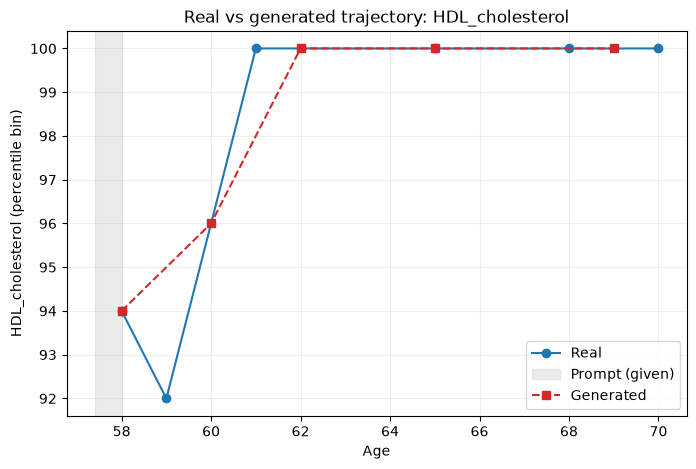

In [24]:
ehr_utils.plot_real_vs_generated(real_seq=full_history, generated_seq=generated, lab="HDL_cholesterol", disease="E11", prompt_str=prompt)

# Training with GRS as additional inputs

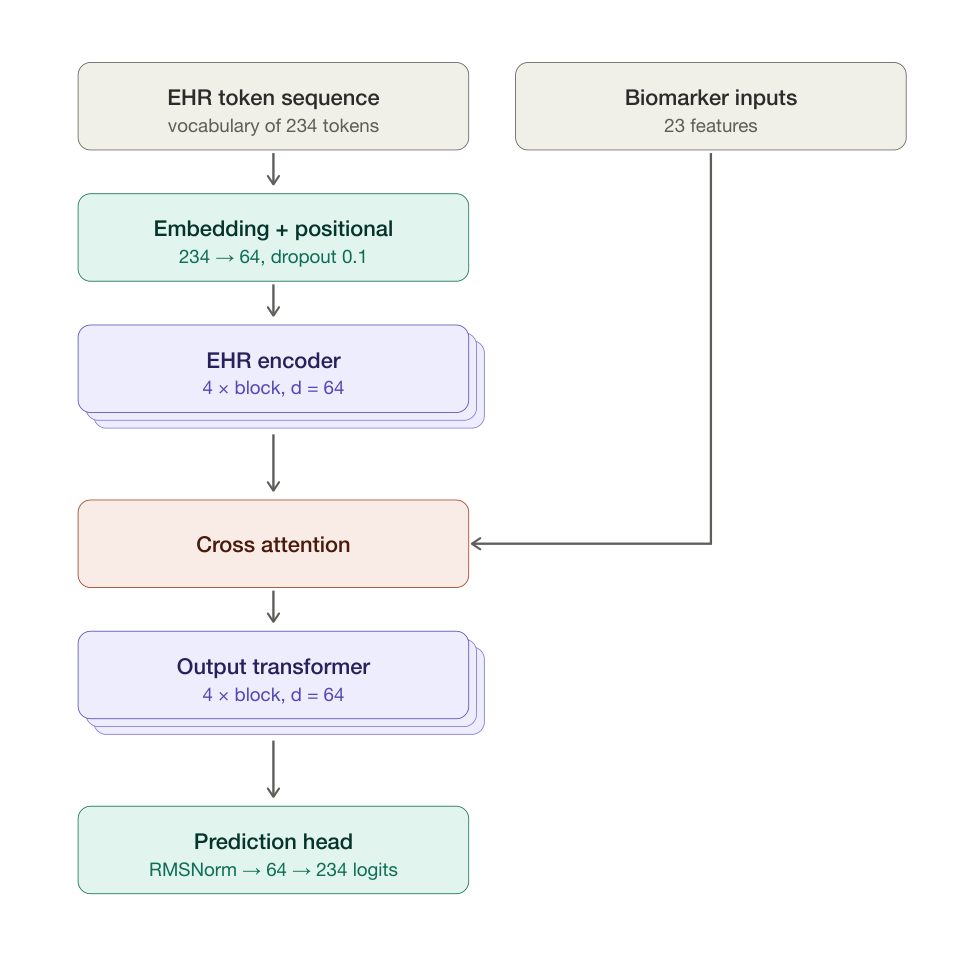

In [25]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../docs/static/figures/ehr-transformer-with-grs.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

In [26]:
df_grs, trait_kind = ehr_utils.load_grs_predictions(results_dir=RESULTS_DIR)
print(f"preds: {df_grs.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")
display(df_grs.head())

preds: (1401, 315)  continuous=237  binary=78


,Alanine_aminotransferase,Albumin_BIOCH,Alkaline_phosphatase,Apolipoprotein_A,Apolipoprotein_A1,Apolipoprotein_B_BIOCH,Apolipoprotein_B_METAB,Aspartate_aminotransferase,Average_Diameter_for_HDL_Particles,Average_Diameter_for_VLDL_Particles,...,Urea,VLDL_Cholesterol,Vitamin_D,Waist_circumference,Weight_ANTHRO,Weight_IMPED,White_blood_cell_leukocyte_count,Whole_body_fat_free_mass,Whole_body_fat_mass,Whole_body_water_mass
ID,,,,,,,,,,,,,,,,,,,,,
10002,22.542770,45.750916,78.095764,1.516815,1.461326,1.079866,0.920252,25.107138,9.593956,38.873093,...,5.371122,0.798058,49.158367,92.140720,80.53792,80.50510,6.893251,54.358200,26.746830,39.798134
10004,28.100965,44.744290,82.361740,1.553589,1.489705,0.935423,0.784924,26.449203,9.604637,38.699020,...,5.384340,0.621664,46.077310,88.349655,76.54702,76.31497,6.289234,52.096508,23.333853,37.992413
10005,22.484835,45.355780,90.182304,1.544894,1.473571,1.035341,0.870705,27.218803,9.558011,39.674297,...,5.420731,0.774767,50.846190,90.930595,76.09740,75.78765,6.923183,51.953290,26.081810,37.976200
10007,23.979660,45.518280,87.363410,1.639348,1.566334,1.016251,0.852204,24.755083,9.717243,38.340710,...,5.477870,0.692197,45.338993,87.590614,70.78199,70.52157,6.385489,49.508488,22.894985,36.236700
10008,26.343996,46.066658,88.195015,1.447073,1.392570,1.073851,0.893995,26.636324,9.563436,38.972090,...,5.484081,0.751684,54.548225,87.538025,78.50737,78.36777,6.650043,52.501266,23.214048,38.252075


In [27]:
df_seq_test = pd.read_csv("../reference_data/eir-transformer/df_ehr_test.csv", index_col="ID")
df_seq = pd.concat([df_seq_train, df_seq_test])
df_grs_matched = ehr_utils.match_grs_to_sequences(df_seq=df_seq, df_grs=df_grs)

In [28]:
df_grs_train = df_grs_matched[df_grs_matched.index.isin(df_seq_train.index)]
df_grs_test  = df_grs_matched[df_grs_matched.index.isin(df_seq_test.index)]
df_grs_train.to_csv("../reference_data/eir-transformer/df_grs.csv")
df_grs_test.to_csv("../reference_data/eir-transformer/df_grs_test.csv")

## Config setup

In [29]:
biomarker_columns = [
    "Cholesterol",                    
    "LDL_direct",                     
    "Glycated_haemoglobin_HbA1c",     
    "Alanine_aminotransferase",
    "Aspartate_aminotransferase",
    "Apolipoprotein_A",
    "Apolipoprotein_B_BIOCH",
    "Gamma_glutamyltransferase",
    "Alkaline_phosphatase",
    "Albumin_BIOCH",
    "Total_protein",
    "Direct_bilirubin",
    "Total_bilirubin",
    "C_reactive_protein",
    "Urate",
    "Calcium",
    "Phosphate",
    "Creatinine_BIOCH",
    "Cystatin_C",
    "Urea",
    "IGF_1",
    "Vitamin_D",
    "Lipoprotein_A",
]

In [30]:
ehr_utils.write_grs_tabular_config(
    input_source="../reference_data/eir-transformer/df_grs.csv",
    out_path="../configs/eir-transformer-with-grs/input_tabular.yaml",
    columns=biomarker_columns,
)
ehr_utils.write_grs_tabular_config(
    input_source="../reference_data/eir-transformer/df_grs_test.csv",
    out_path="../configs/eir-transformer-with-grs/input_tabular_test.yaml",
    columns=biomarker_columns,
)

Similar to the above, we need to edit the configs a bit here in the case we are running on GitHub Codespaces. Feel free to use the same parameters of `5` epochs and a sequence length of `32` as before when calling `edit_config`.

In [31]:
# Same as above, only needed if you want to shorten the run.
# eir_utils.edit_config(
#     n_epochs=20,
#     max_len=64,
#     globals_config="../configs/eir-transformer-with-grs/globals.yaml",
#     output_config="../configs/eir-transformer-with-grs/output_sequence.yaml",
# )

In [32]:
if TRAIN_FROM_SCRATCH:
    !eirtrain \
        --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
        --input_configs  "../configs/eir-transformer-with-grs/input_tabular.yaml" \
        --fusion_configs "../configs/eir-transformer/fusion.yaml" \
        --output_configs "../configs/eir-transformer-with-grs/output_sequence.yaml"

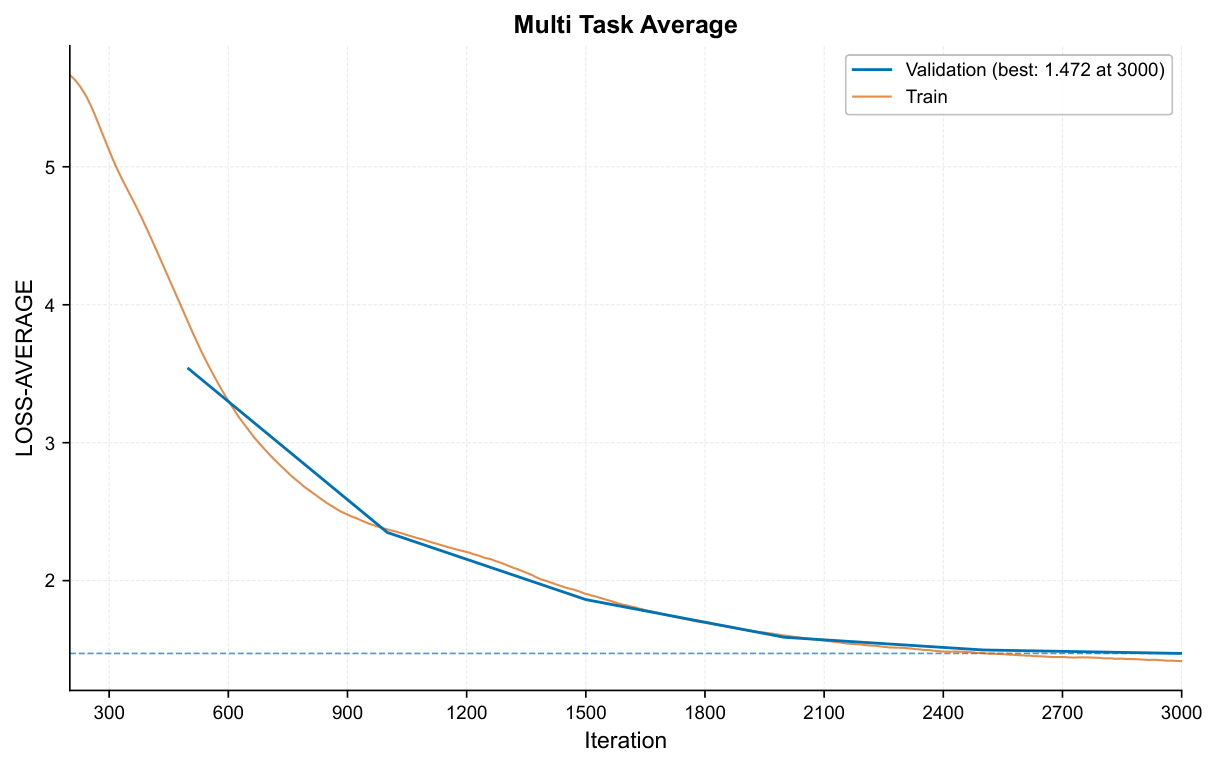

In [33]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer-with-grs/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

## Comparing loss with and without GRS

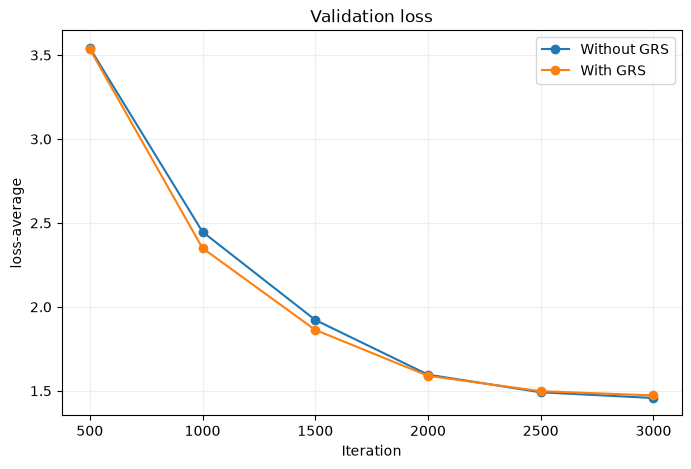

In [34]:
ehr_utils.plot_validation_loss(runs={
    "Without GRS": "../runs/ehr_transformer",
    "With GRS":    "../runs/ehr_transformer-with-grs",
})

### Takeaways from loss curves: Why is there such a little difference in the losses?

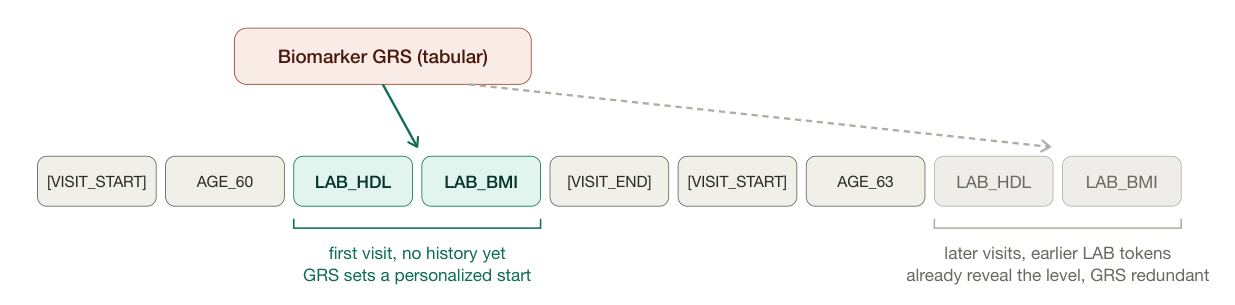

In [35]:
import fitz
from IPython.display import Image, display
doc = fitz.open("../docs/static/figures/ehr-tokens-grs.pdf")
display(Image(data=doc.load_page(0).get_pixmap(dpi=150).tobytes()))

Notice how the losses are quite similar here. 
When we train these sequence models, the loss is computed for each position in the sequence at once, 
where the model is conditioned on everything that comes before in the sequence. 

Now, in our simulation, a persons lab values are generated as a function of the original underlying genetic percentiles
(i.e. the values changes as the person ages, but the genetic percentiles determine the starting point). 
So once the model has seen a visit or two, the earlier `LAB_..._%` tokens already show where this individual sits,
and for the rest of the sequence the model is being conditioned on this information.

Since the loss is computed *over the whole sequence*,
it's plausible that even though the GRS values are useful for the prediction of the first tokens
in the sequence, they do not help for the majority of the sequence 
once the original percentiles are already visible in the context.

Below, in the *Comparing trajectory generation* section, we will analyze
a bit whether there is a difference in the model performance at predicting
trajectories when we don't know the first baseline visit, i.e. 
we might only give the model `SEX_2 [VISIT_START] AGE_60` as a prompt, 
which means the GRS based model can use the tabular inputs to
"seed" the trajectories, whereas the non-GRS model has no additional
information and will likely start from the population mean.

# Testing with GRS input

In [36]:
full_history = ehr_utils.load_test_sample(index=0)
prompt = trim_sequence(full_history, stop_when=lambda t: t == "[VISIT_END]")
tabular_input = ehr_utils.load_test_grs(index=0, columns=biomarker_columns)

In [37]:
prompt

'SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_94% LAB_Body_mass_index_BMI_IMPED_10% LAB_Total_Triglycerides_24% LAB_Systolic_blood_pressure_automated_reading_30% [VISIT_END]'

In [38]:
tabular_input

{'Cholesterol': 6.1145873,
 'LDL_direct': 3.7932913,
 'Glycated_haemoglobin_HbA1c': 36.74147,
 'Alanine_aminotransferase': 26.33017,
 'Aspartate_aminotransferase': 27.550787,
 'Apolipoprotein_A': 1.6436721,
 'Apolipoprotein_B_BIOCH': 1.067218,
 'Gamma_glutamyltransferase': 38.039497,
 'Alkaline_phosphatase': 79.44806,
 'Albumin_BIOCH': 45.703136,
 'Total_protein': 71.72162,
 'Direct_bilirubin': 3.3085146,
 'Total_bilirubin': 19.51425,
 'C_reactive_protein': 2.1354516,
 'Urate': 301.092,
 'Calcium': 2.3919413,
 'Phosphate': 1.1971753,
 'Creatinine_BIOCH': 75.11925,
 'Cystatin_C': 0.8391408,
 'Urea': 5.454428,
 'IGF_1': 20.052748,
 'Vitamin_D': 49.1099,
 'Lipoprotein_A': 40.112858}

In [39]:
ehr_utils.set_manual_inputs(prompts=prompt,
                  config_path="../configs/eir-transformer-with-grs/output_sequence_test.yaml",
                  tabular=tabular_input)

In [40]:
!eirpredict \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs "../configs/eir-transformer-with-grs/input_tabular_test.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence_test.yaml" \
    --model_path ../runs/ehr_transformer-with-grs/saved_models/ehr_transformer-with-grs_checkpoint_* \
    --output_folder "../runs/ehr_transformer-with-grs/test_set_predictions" 

01:52:41 - INFO - eir.train_utils.utils - Global random seed set to 0.


01:52:41 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.


01:52:41 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
01:52:41 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
01:52:41 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_transformer-with-grs/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:41 - INFO - eir.setup.input_setup_modules.setup_sequence - Minimum word/token frequency will be set to 0 as vocabulary is loaded from file ../runs/ehr

Progress: 2810it [00:00, 5805908.49it/s]
01:52:42 - INFO - eir.setup.input_setup - Setting up tabular inputs 'biomarker_inputs' from ../reference_data/eir-transformer/df_grs_test.csv.


01:52:42 - INFO - eir.setup.input_setup - Setting up sequence inputs 'ehr' from ../reference_data/eir-transformer/df_ehr_test.csv.
01:52:42 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/ehr_transformer-with-grs/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:42 - INFO - eir.setup.input_setup_modules.setup_sequence - Minimum word/token frequency will be set to 0 as vocabulary is loaded from file ../runs/ehr_transformer-with-grs/serializations/sequence_input_serializations/ehr/vocab.json.
01:52:42 - WARNING - eir.experiment_io.input_object_io - Expected 'model_config' to be the same in current input configuration
'SequenceModelConfig(model_init_config=BasicTransformerFeatureExtractorModelConfig(num_heads=8, num_layers=4, dim_feedforward='auto', dropout=0.1), model_type='eir-input-sequence-from-linked-output-default', embedding_dim=64, position='encode', position_dropout=0.1, window_size=0, poo

ehr: 2810it [00:00, 67212.19it/s]
01:52:42 - INFO - eir.data_load.datasets - Filtered out 0 samples that had no inputs or no target labels.
01:52:42 - INFO - eir.data_load.datasets - Using total of 2810 samples with following counts per modality (note missing tabular modalities have been imputed already):
Available biomarker_inputs: 2810 (missing: 0, missing IDs: [])
Available ehr: 2810 (missing: 0, missing IDs: [])
01:52:42 - INFO - eir.data_load.storage_engine - Test/Validation input storage is using 0.3430MB of memory holding 2810 samples.
01:52:42 - INFO - eir.models.input.sequence.transformer_models - Setting dim_feedfoward to 256 based on embedding_dim=64 and 'auto' option.
01:52:42 - INFO - eir.models.input.sequence.transformer_models - Setting dim_feedfoward to 256 based on embedding_dim=64 and 'auto' option.


01:52:42 - INFO - eir.models.meta.meta - Tying weights for ehr with direct sharing
01:52:42 - INFO - eir.models.meta.meta - Weight tying applied for modules: ehr
01:52:42 - INFO - eir.models.model_setup_modules.model_io - Successfully loaded 139/139 modules from ../runs/ehr_transformer-with-grs/saved_models/ehr_transformer-with-grs_checkpoint_3000_perf-average=-0.4724.pt.


01:52:42 - INFO - eir.train_utils.accelerator - Using accelerator: MPSAccelerator (auto-determined from 'auto')
01:52:42 - INFO - eir.train_utils.accelerator - Using strategy: SingleDeviceStrategy (auto-determined from 'auto')
01:52:42 - INFO - eir.train_utils.accelerator - Using precision: 32-true
01:52:42 - INFO - eir.train_utils.accelerator - Using devices: 1 (auto-determined from 'auto')
01:52:42 - INFO - eir.train_utils.accelerator - Using num_nodes: 1
01:52:42 - INFO - eir.train_utils.accelerator - Running in single-process mode


In [41]:
with open("../runs/ehr_transformer-with-grs/test_set_predictions/results/ehr/ehr/samples/0/manual/0_generated.txt") as infile:
    generated = infile.read()

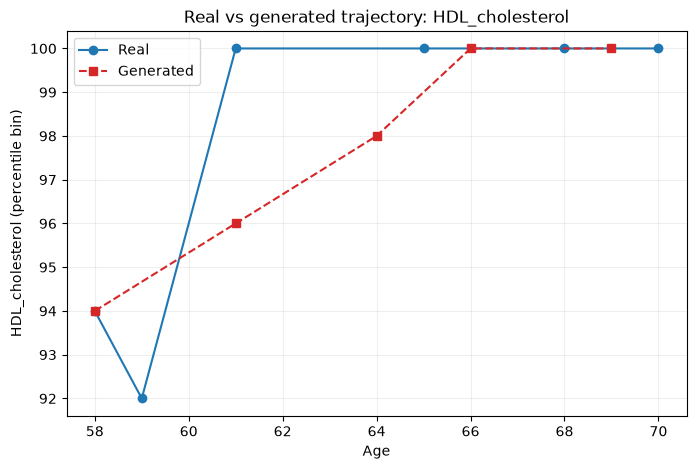

In [42]:
ehr_utils.plot_real_vs_generated(real_seq=full_history, generated_seq=generated, lab="HDL_cholesterol", disease="E11")

## Comparing trajectory generation

As you might be familiar by interacting with LLMs like ChatGPT, these models are somewhat stochastic in the sense that you might ask it the same question twice, but get slightly different answers. This is because these models generate a probability distribution across all the tokens in their vocabulary at each step when producing the next token, then they *sample* from this distribution to choose what token is "assigned" as the next one.

The same is true for our little EHR transformer, it's possible that by chance a low probability token is sampled as the first token in the sequence, and once this is assigned, the rest of the sequence is conditioned on this "unlucky" token, and we might get an overall sequence that is not very "correct" (this is loosely related to the concept of "hallucination" in LLMs). 

This is why we might not want to assign a concrete trajectory from just a single generated sequence. By drawing many samples from the same prompt (`n_samples` in the functions below), and averaging them at each visit (both the age and the values), an "unlucky draw" is less likely to influence the final trajectory, and instead we end up with an average 

In [43]:
sample_index = 0

full_history = ehr_utils.load_test_sample(index=sample_index)
visit_start_prompt = trim_sequence(full_history, stop_when=lambda t: t.startswith("AGE_"))

In [44]:
print(visit_start_prompt)

SEX_2 [VISIT_START] AGE_58


In [45]:
print("Running prediction with sequence only model...")
gen_plain = ehr_utils.generate_from_prompt(
    prompt=visit_start_prompt,
    globals_config="../configs/eir-transformer/globals.yaml",
    output_config="../configs/eir-transformer/output_sequence_test.yaml",
    model_glob="../runs/ehr_transformer/saved_models/ehr_transformer_*",
    output_folder="../runs/ehr_transformer/test_set_predictions",
    n_samples=64,
)

print("Running prediction with sequence+GRS model...")
gen_grs = ehr_utils.generate_from_prompt(
    prompt=visit_start_prompt,
    globals_config="../configs/eir-transformer-with-grs/globals.yaml",
    output_config="../configs/eir-transformer-with-grs/output_sequence_test.yaml",
    model_glob="../runs/ehr_transformer-with-grs/saved_models/ehr_transformer-with-grs_checkpoint_*",
    output_folder="../runs/ehr_transformer-with-grs/test_set_predictions",
    input_config="../configs/eir-transformer-with-grs/input_tabular_test.yaml",
    tabular=ehr_utils.load_test_grs(index=sample_index, columns=biomarker_columns),
    n_samples=64,
)

Running prediction with sequence only model...


Running prediction with sequence+GRS model...


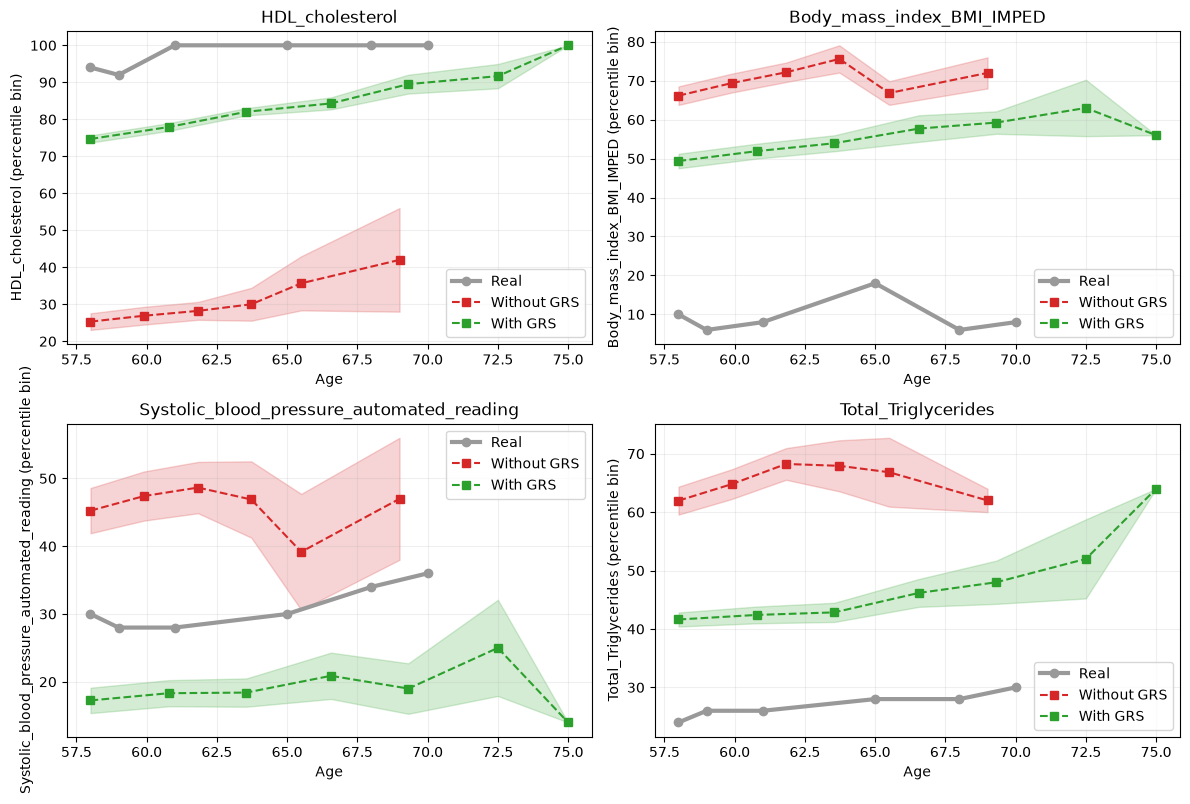

In [46]:
ehr_utils.plot_trajectory_comparison(
    real_seq=full_history,
    generated={"Without GRS": gen_plain, "With GRS": gen_grs},
    labs=["HDL_cholesterol", "Body_mass_index_BMI_IMPED",
          "Systolic_blood_pressure_automated_reading", "Total_Triglycerides"],
)

### Trajectory generation performance analysis

In [47]:
ehr_utils.trajectory_mae(
    real_seq=full_history,
    generated={"Without GRS": gen_plain, "With GRS": gen_grs},
    labs=["HDL_cholesterol", "Body_mass_index_BMI_IMPED",
          "Systolic_blood_pressure_automated_reading", "Total_Triglycerides"],
)

,Without GRS,With GRS
HDL_cholesterol,66.315972,14.319036
Body_mass_index_BMI_IMPED,61.023048,46.529105
Systolic_blood_pressure_automated_reading,14.729286,11.191483
Total_Triglycerides,38.299270,18.508578


## Visualizing latent representations

So far, we have explore and plotted the generated trajectories for given biomarkers by themselves.

Another type of analysis we can do is looking at the whole trajectory of samples,
to see if there are general patterns that define certain groups or clusters of individuals that share a similar overall trajectory.

One way to do this is running the whole, known sequences of samples through our trained transformer model. As it goes through the layers
in the model, the original discrete sequence is converted to more and more refined numerical representations
(i.e. "latents", which refer to a given numerical representation of the input in the neural network after it has been processed by some of the layers).

We can extract these numerical representation and analyze them. For example below, we are taking
the representations, then (specifically the `final_norm` layer in the model), average the 
representations across time steps and patient replicates, then we reduce to a 2D representation via UMAP, 
and finally plot and color by GRS.

In a "real" analysis, we could for example imagine taking the trajectories of all individuals in our dataset that are diagnosed with a disease
such as T2D, then if we extract their embeddings and cluster them, we might be able to identify clusters of trajectories,
e.g. some individuals might get T2D over a long time period thought high BMI. Others might end up with the disease e.g. thorugh high HbA1c without 
an obesity pattern. Distinct clusters might indicate different trajectories to the same disease.

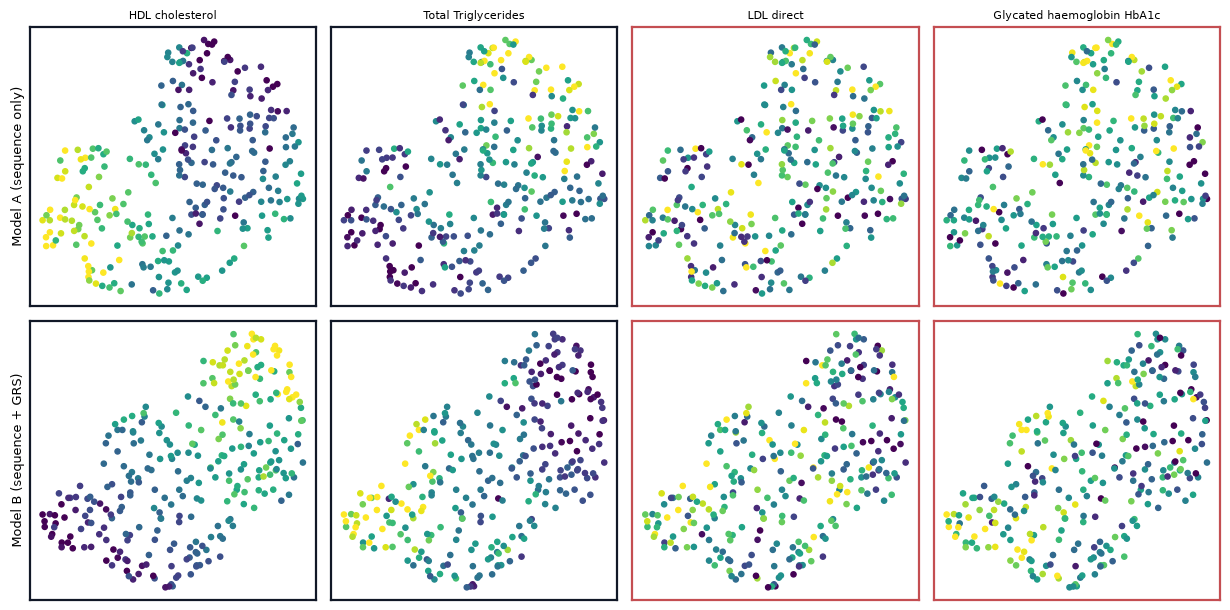

In [48]:
REF   = Path("../reference_data/eir-transformer")
LAYER = "latents/latent_outputs/predict/output_modules.ehr.final_norm"

test = pd.read_csv(REF / "df_ehr_test.csv")
sequences = dict(zip(test["ID"].astype(str), test["Sequence"]))

runs = {"Model A (sequence only)":  "../runs/ehr_transformer",
        "Model B (sequence + GRS)": "../runs/ehr_transformer-with-grs"}

panels = {}
for name, run in runs.items():
    latents = la.load_latents(Path(run) / LAYER)
    emb = la.to_patient_matrix(latents=latents, sequences=sequences)
    grs = la.load_grs([REF / "df_grs.csv", REF / "df_grs_test.csv"], emb.index)
    panels[name] = (la.umap_embedding(emb=emb), grs)

la.plot_umap_grid(
    panels=panels,
    traits=["HDL_cholesterol",
            "Total_Triglycerides",
            "LDL_direct",
            "Glycated_haemoglobin_HbA1c"],
    drivers=["HDL_cholesterol",
             "Total_Triglycerides",
             "Body_mass_index_BMI_IMPED",
             "Systolic_blood_pressure_automated_reading",
             "I10",
             "I25",
             "E11"],
    style="scatter",)

**Takeaways from clustering**

The two panels with a black frame are traits the models actually read in the sequences
(`LAB_HDL_cholesterol_...` and `LAB_Total_Triglycerides_...`). The two with a red frame
are traits that only reach a model through the GRS input, if at all.

- Both models lay the individuals out along a clear HDL and triglyceride gradient, which
  is what we would hope for, since those values are written into the trajectories they
  were trained on.
- For LDL and HbA1c, Model A shows no structure to speak of. That makes sense, as it never
  saw anything related to them.
- Model B does have those two as tabular input, but the coloring there is still close to
  random. So the GRS values are available to it without being strongly reflected in how it
  represents an individual, which is the same picture the loss curves gave us.

# Summary

We simulated EHR trajectories from the genetically predicted trait percentiles of the
PennCATH individuals, tokenized them, and trained a GPT style transformer to predict the
next token. We then trained the same model again with the GRS values as a second, tabular
input, and compared the two.

What came out of it:

- **The validation losses are nearly the same**, 1.4573 without GRS against 1.4724 with
  it. Adding the GRS input did not make next-token prediction easier.
- **The reason is in how the loss is computed.** It averages over every position in the
  sequence, and after a visit or two the `LAB_..._%` tokens already say where an individual
  sits, so there is not much left for the GRS values to add.
- **Taking the baseline visit away changes that.** Prompted with only
  `SEX_2 [VISIT_START] AGE_58`, the model without GRS falls back on the population average,
  while the GRS model starts near this individual's actual level. For HDL the mean absolute
  error went from 66.3 down to 14.3.
- **The latent space is organized by what a model reads in the sequence** rather than by
  what it is handed as tabular input.

Two things worth keeping in mind:

- The data is simulated, and the trajectories are by construction a function of the genetic
  percentiles, so there is some circularity here. This is a demonstration of how to combine
  two modalities in one model, not evidence that GRS values help predict real health
  trajectories.
- Both models saw around 11,000 sequences for 3000 iterations, which is very small for a
  transformer.